# Orange County Analysis

In [ ]:
# Import statements
import pandas as pd

from utils import (
    load_census,
    condense_ripa_races,
    add_search_and_hit_indicators,
    policing_tables_by_year, 
    census_rollup, 
    add_per_capita_rates_by_year, 
    concat_policing_tables,
    compute_prosecution_rates,
    merge_policing_with_prosecution,
    add_disparity_metrics,
    visualization_setup,
    visualize
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [4]:
# Load in policing data
policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2019_2023.csv")

<positron-console-cell-4>:3: DtypeWarning: Columns (0: time_of_stop, 1: school_code, 2: school_name, 3: ros_warning_cds, 4: ros_citation_cds, 5: ros_in_field_cite_release_cds, 6: ros_custodial_wout_warrant_cds) have mixed types. Specify dtype option on import or set low_memory=False.


In [5]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['year'] = prosecution['filed_date'].dt.year

In [6]:
# Load in census data
census = load_census("06059")

# Policing Analysis

In [ ]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_stop"].isin([1, 2])]

(511178, 170)

In [7]:
# Collapse all of the non-relevant racial categories in RIPA data to "Other"
policing = condense_ripa_races(policing)

In [8]:
# Create search and hit columns
policing = add_search_and_hit_indicators(policing)

In [14]:
# Create one policing table per year
tables = policing_tables_by_year(policing, [2019, 2020, 2021, 2022, 2023])

# Roll-up the census data to be more coarse to match policing data hierarchy
# Note that Hispanic or Latino is Non-White Hispanic or Latino
census_coarse = census_rollup(census)

# Adds per-capita rates to each table
tables = add_per_capita_rates_by_year(tables, census_coarse)

# Create one big master table with all years and rates
policing_all = concat_policing_tables(tables)
policing_all

,Perceived Race,Search Count,Hit Count,Stop Count,Search Rate,Hit Rate,"Searches per 1,000","Hits per 1,000","Stops per 1,000",Year
0,Asian,110,52,2978,0.036938,0.472727,0.157340,0.074379,4.259616,2019
1,Black/African American,257,102,1777,0.144626,0.396887,5.212559,2.068798,36.041700,2019
2,Hispanic/Latino,2029,799,14260,0.142286,0.393790,1.866890,0.735163,13.120679,2019
3,Other,135,54,3796,0.035564,0.400000,0.881938,0.352775,24.798787,2019
4,White,2480,1160,23042,0.107630,0.467742,2.068986,0.967751,19.223213,2019
5,Asian,122,54,2344,0.052048,0.442623,0.174504,0.077240,3.352767,2020
6,Black/African American,217,108,1372,0.158163,0.497696,4.401266,2.190492,27.827357,2020
7,Hispanic/Latino,2003,881,11642,0.172049,0.439840,1.842968,0.810611,10.711847,2020
8,Other,156,60,2793,0.055854,0.384615,1.019128,0.391972,18.246315,2020
9,White,1955,1015,16917,0.115564,0.519182,1.630995,0.846782,14.113319,2020


## Prosecution Rates

In [15]:
prosecution_rates = compute_prosecution_rates(
    prosecution,
    race_col="canonical_race",
    year_col="year",
    convicted_col="was_convicted",
    enhancement_col="is_enhancement_charge"
)
prosecution_rates

,canonical_race,year,total_cases,conviction_rate,enhancement_rate
0,Asian,2021,4578,0.706204,0.107907
1,Asian,2022,4228,0.721618,0.099811
2,Asian,2023,3002,0.751499,0.081945
3,Black,2021,5250,0.729333,0.075152
4,Black,2022,6609,0.730519,0.064458
5,Black,2023,3312,0.666667,0.045592
6,Latinx,2021,50491,0.771801,0.092506
7,Latinx,2022,54525,0.771646,0.083556
8,Latinx,2023,27383,0.744294,0.076142
9,Other,2021,4653,0.617021,0.146357


# Disparity Ratios

In [16]:
# Merge policing and prosecution data into one table based on common policing race label
analysis = merge_policing_with_prosecution(
    policing_all,
    prosecution_rates,
    pros_race_col="canonical_race",
    pros_year_col="year"
)

In [17]:
# Add White-normalized ratios and a search-hit gap
analysis = add_disparity_metrics(analysis)

# Keep plots consistent across runs
analysis = visualization_setup(analysis)

In [ ]:
# Master table with all policing and prosecution data by race x year
analysis

,Perceived Race,Search Count,Hit Count,Stop Count,Search Rate,Hit Rate,"Searches per 1,000","Hits per 1,000","Stops per 1,000",Year,Canonical Prosecution Race,Total Prosecution Cases,Conviction Rate,Enhancement Rate,"Stops per 1,000 (White=1)","Searches per 1,000 (White=1)",Search Rate (White=1),Hit Rate (White=1),Conviction Rate (White=1),Enhancement Rate (White=1)
1,Black/African American,257,102,1777,0.144626,0.396887,5.212559,2.068798,36.041700,2019,NaN,NaN,NaN,NaN,1.874905,2.519379,1.343737,0.848517,NaN,NaN
2,Hispanic/Latino,2029,799,14260,0.142286,0.393790,1.866890,0.735163,13.120679,2019,NaN,NaN,NaN,NaN,0.682544,0.902322,1.321999,0.841896,NaN,NaN
4,White,2480,1160,23042,0.107630,0.467742,2.068986,0.967751,19.223213,2019,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN
0,Asian,110,52,2978,0.036938,0.472727,0.157340,0.074379,4.259616,2019,NaN,NaN,NaN,NaN,0.221587,0.076047,0.343191,1.010658,NaN,NaN
3,Other,135,54,3796,0.035564,0.400000,0.881938,0.352775,24.798787,2019,NaN,NaN,NaN,NaN,1.290044,0.426266,0.330427,0.855172,NaN,NaN
6,Black/African American,217,108,1372,0.158163,0.497696,4.401266,2.190492,27.827357,2020,NaN,NaN,NaN,NaN,1.971709,2.698516,1.368618,0.958616,NaN,NaN
7,Hispanic/Latino,2003,881,11642,0.172049,0.439840,1.842968,0.810611,10.711847,2020,NaN,NaN,NaN,NaN,0.758989,1.129965,1.488778,0.847180,NaN,NaN
9,White,1955,1015,16917,0.115564,0.519182,1.630995,0.846782,14.113319,2020,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN
5,Asian,122,54,2344,0.052048,0.442623,0.174504,0.077240,3.352767,2020,NaN,NaN,NaN,NaN,0.237561,0.106992,0.450380,0.852540,NaN,NaN
8,Other,156,60,2793,0.055854,0.384615,1.019128,0.391972,18.246315,2020,NaN,NaN,NaN,NaN,1.292844,0.624851,0.483315,0.740811,NaN,NaN


# Visualizations

### Outcome Tests
1. **Hit Rate** (hits / searches): Conditional on being searched, how often is contraband found?
2. **Conviction Rate** (convictions / cases): Conditional on charges being filed, how often does the case result in conviction?
3. **Enhancement Rate** (enhancements / cases): Conditional on a case existing, how often are sentence-enhancing charges applied?

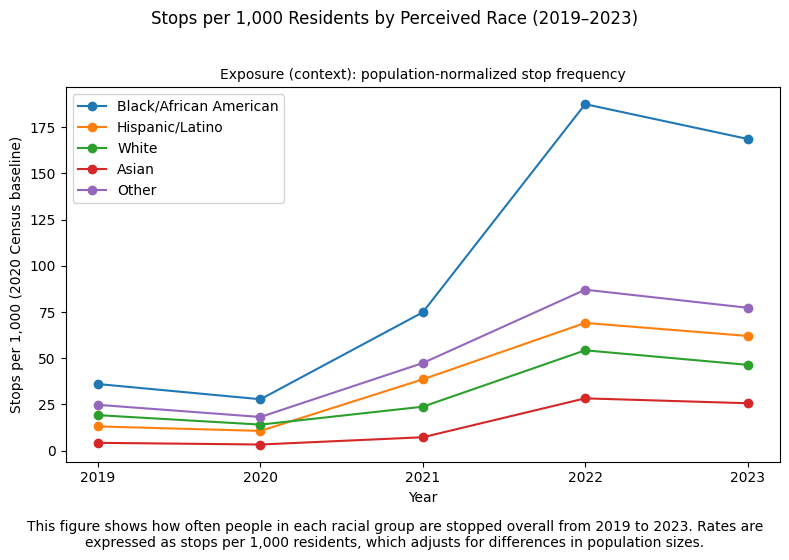

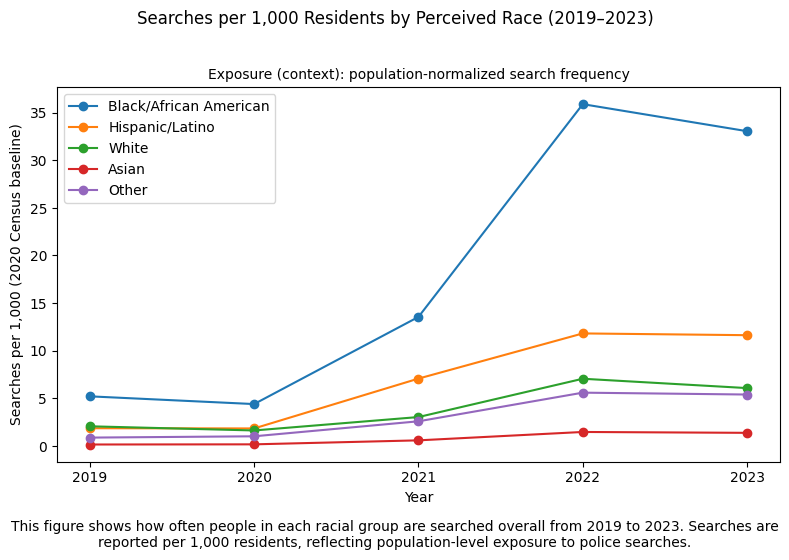

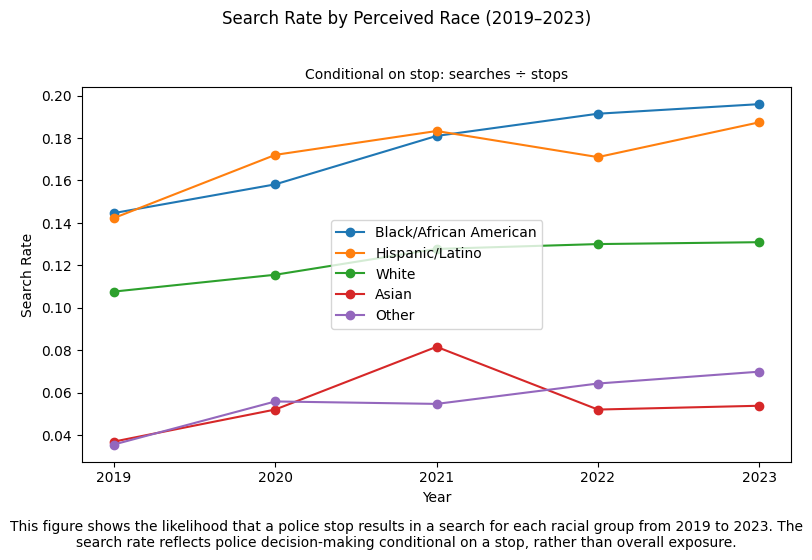

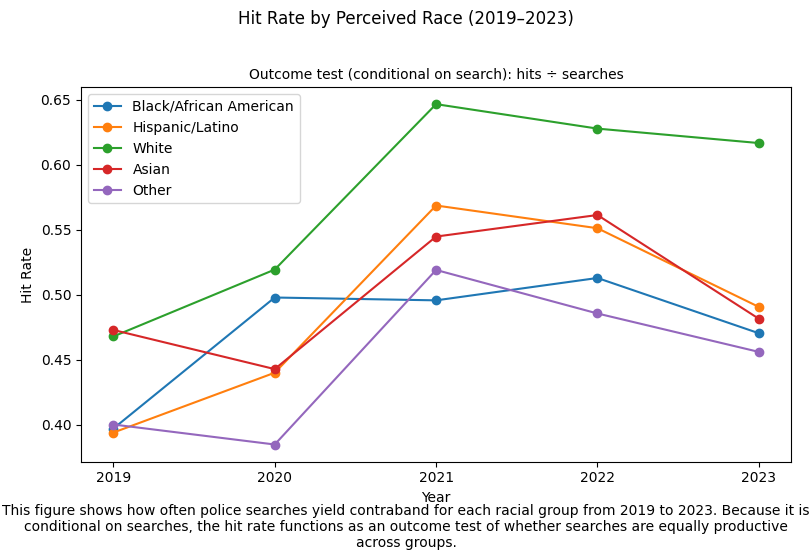

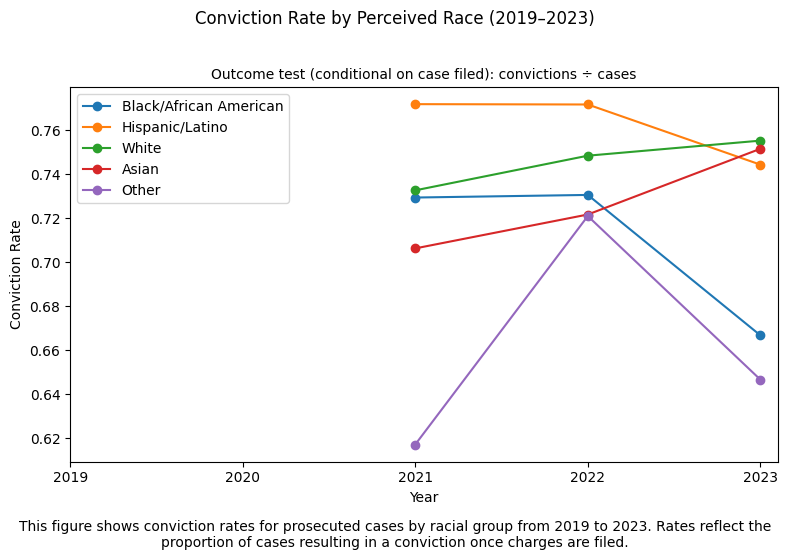

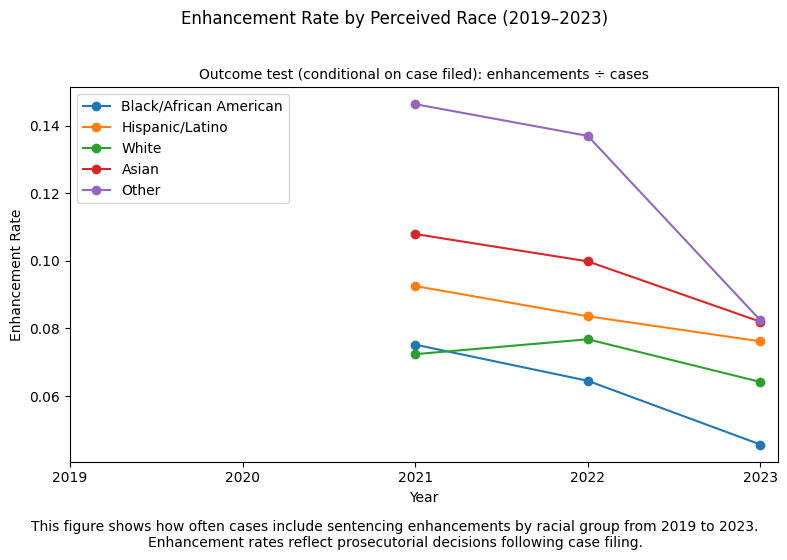

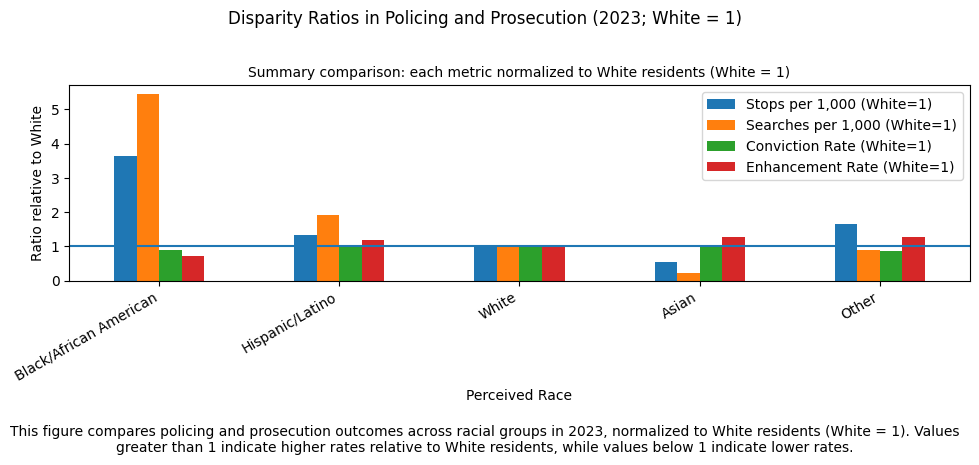

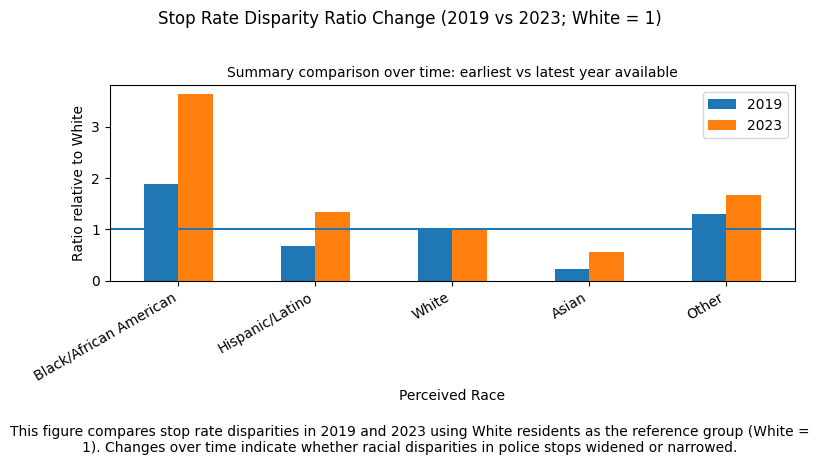

In [23]:
visualize(analysis)